## Training

The home and away form and elos seemed to create overfitting (as one would expect); so we just switched to elo diffs and form diffs

In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler

MODEL_DATA_DIR = Path('model_data')

N_VALUES = [5, 10, 15, 20]

FEATURES = [
    'elo_diff',
    'form_diff',
    'comp_form_diff'
    # 'home_elo',
    # 'away_elo',
    # 'home_form',
    # 'away_form',
    # 'home_comp_form',
    # 'away_comp_form',
]

def load_and_engineer(path):
    df = pd.read_csv(path)
    df['elo_diff']       = df['home_elo']       - df['away_elo']
    df['form_diff']      = df['home_form']       - df['away_form']
    df['comp_form_diff'] = df['home_comp_form']  - df['away_comp_form']
    return df

print('Imports ready.')

Imports ready.


### Logistic Regression

N=10 seems to be the best, which is logical as it encompasses qualifying matches for comp form and late friendlies as well as final qualifying matches for total form.

In [29]:
lr_results = []

for n in N_VALUES:
    train = load_and_engineer(MODEL_DATA_DIR / f'training_data_{n}.csv')
    val   = load_and_engineer(MODEL_DATA_DIR / f'validation_data_{n}.csv')

    X_train, y_train = train[FEATURES], train['result']
    X_val,   y_val   = val[FEATURES],   val['result']

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)

    train_acc   = accuracy_score(y_train, model.predict(X_train))
    val_acc     = accuracy_score(y_val,   model.predict(X_val))
    val_logloss = log_loss(y_val, model.predict_proba(X_val))

    lr_results.append({
        'N':           n,
        'train_acc':   round(train_acc,   4),
        'val_acc':     round(val_acc,     4),
        'val_logloss': round(val_logloss, 4),
    })
    print(f'N={n:2d} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | val log-loss: {val_logloss:.3f}')

lr_results_df = pd.DataFrame(lr_results)
print()
lr_results_df

N= 5 | train acc: 0.549 | val acc: 0.562 | val log-loss: 1.050
N=10 | train acc: 0.565 | val acc: 0.578 | val log-loss: 1.037
N=15 | train acc: 0.555 | val acc: 0.547 | val log-loss: 1.059
N=20 | train acc: 0.562 | val acc: 0.547 | val log-loss: 1.044



,N,train_acc,val_acc,val_logloss
0,5,0.5495,0.5625,1.0497
1,10,0.5651,0.5781,1.0373
2,15,0.5547,0.5469,1.0587
3,20,0.5625,0.5469,1.0439


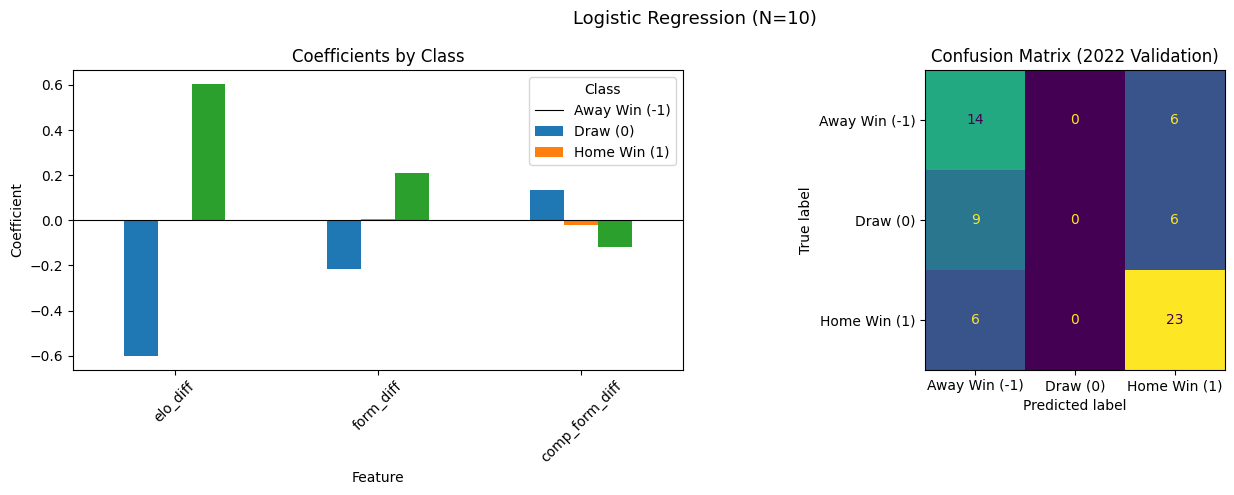

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

scaler = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
y_train, y_val = train['result'], val['result']

lr_best = LogisticRegression(random_state=42, max_iter=1000)
lr_best.fit(X_train, y_train)

LABELS = ['Away Win (-1)', 'Draw (0)', 'Home Win (1)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression (N=10)', fontsize=13)

# Coefficient bar chart — one set of coefficients per class
coef_df = pd.DataFrame(lr_best.coef_, columns=FEATURES, index=lr_best.classes_)
coef_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Coefficients by Class')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Coefficient')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Class', labels=LABELS)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_best.predict(X_val),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

### Gradient Boosted Trees

Trees seem very prone to overfitting and not great for soccer as compared to the logistic regression.

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gbt_results = []

for n in N_VALUES:
    train = load_and_engineer(MODEL_DATA_DIR / f'training_data_{n}.csv')
    val   = load_and_engineer(MODEL_DATA_DIR / f'validation_data_{n}.csv')

    X_train, y_train = train[FEATURES].values, train['result'].values
    X_val,   y_val   = val[FEATURES].values,   val['result'].values

    model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42, learning_rate=0.15)
    model.fit(X_train, y_train) # type: ignore

    train_acc   = accuracy_score(y_train, model.predict(X_train)) # type: ignore
    val_acc     = accuracy_score(y_val,   model.predict(X_val)) # type: ignore
    val_logloss = log_loss(y_val, model.predict_proba(X_val)) # type: ignore

    gbt_results.append({
        'N':           n,
        'train_acc':   round(train_acc,   4),
        'val_acc':     round(val_acc,     4),
        'val_logloss': round(val_logloss, 4),
    })
    print(f'N={n:2d} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | val log-loss: {val_logloss:.3f}')

gbt_results_df = pd.DataFrame(gbt_results)
print()
gbt_results_df

N= 5 | train acc: 0.987 | val acc: 0.422 | val log-loss: 1.353
N=10 | train acc: 0.984 | val acc: 0.547 | val log-loss: 1.140
N=15 | train acc: 0.977 | val acc: 0.484 | val log-loss: 1.332
N=20 | train acc: 0.971 | val acc: 0.547 | val log-loss: 1.240



,N,train_acc,val_acc,val_logloss
0,5,0.9870,0.4219,1.3529
1,10,0.9844,0.5469,1.1405
2,15,0.9766,0.4844,1.3322
3,20,0.9714,0.5469,1.2400


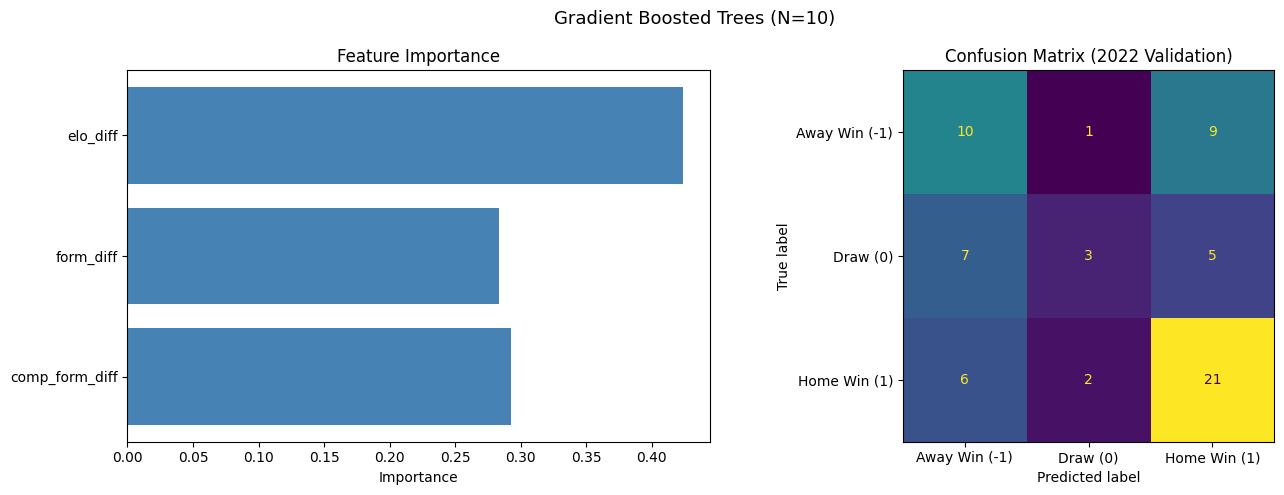

In [32]:
train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

X_train, y_train = train[FEATURES].values, train['result'].values
X_val,   y_val   = val[FEATURES].values,   val['result'].values

gbt_best = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbt_best.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosted Trees (N=10)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, gbt_best.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, gbt_best.predict(X_val),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

### XGBoost

These trees are slightly less prone to overfitting and found to be more accurate than logistic regression at n=10 and with an increased learning rate.

In [33]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

xgb_results = []

# Encode labels to 0,1,2 as XGBoost requires non-negative integer classes
le = LabelEncoder()

for n in N_VALUES:
    train = load_and_engineer(MODEL_DATA_DIR / f'training_data_{n}.csv')
    val   = load_and_engineer(MODEL_DATA_DIR / f'validation_data_{n}.csv')

    X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values) # type: ignore
    X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values) # type: ignore

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.15,
        subsample=0.8,
        reg_lambda=2.0,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0,
    )
    model.fit(X_train, y_train)

    train_acc   = accuracy_score(y_train, model.predict(X_train))
    val_acc     = accuracy_score(y_val,   model.predict(X_val))
    val_logloss = log_loss(y_val, model.predict_proba(X_val))

    xgb_results.append({
        'N':           n,
        'train_acc':   round(train_acc,   4),
        'val_acc':     round(val_acc,     4),
        'val_logloss': round(val_logloss, 4),
    })
    print(f'N={n:2d} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | val log-loss: {val_logloss:.3f}')

xgb_results_df = pd.DataFrame(xgb_results)
print()
xgb_results_df

N= 5 | train acc: 0.870 | val acc: 0.484 | val log-loss: 1.166
N=10 | train acc: 0.898 | val acc: 0.609 | val log-loss: 1.070
N=15 | train acc: 0.875 | val acc: 0.516 | val log-loss: 1.212
N=20 | train acc: 0.857 | val acc: 0.625 | val log-loss: 1.124



,N,train_acc,val_acc,val_logloss
0,5,0.8698,0.4844,1.1662
1,10,0.8984,0.6094,1.0700
2,15,0.8750,0.5156,1.2118
3,20,0.8568,0.6250,1.1243


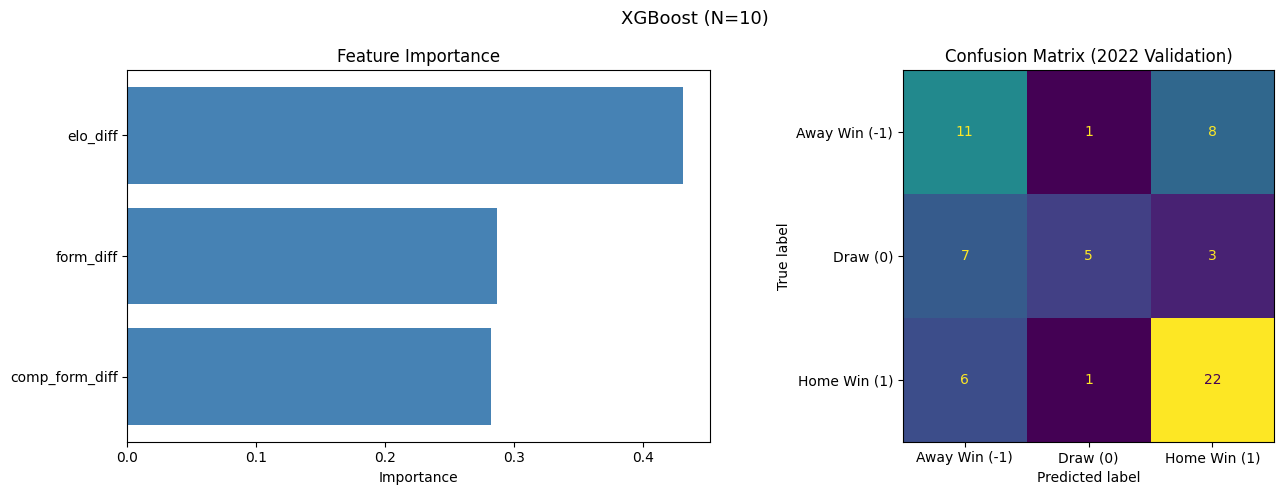

In [34]:
train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values)
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values)

xgb_best = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=10)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()